In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
zip_path = '/content/drive/MyDrive/1st dataset.zip'
extract_path = '/content/bone_data'

os.makedirs(extract_path, exist_ok=True)

!unzip -o "{zip_path}" -d "{extract_path}"

Streaming output truncated to the last 5000 lines.
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3 (1).jpg  
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1 (1).jpg  
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3-rotated1.jpg  
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2-rotated3.jpg  
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotated2-rotated2.jpg  
  inflating: /content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification/train/not fractured/14-rotat

In [ ]:
import os

print(os.listdir('/content/bone_data'))

['README.dataset.txt', 'Bone_Fracture_Binary_Classification']


In [ ]:
print(os.listdir('/content/bone_data/Bone_Fracture_Binary_Classification'))

['Bone_Fracture_Binary_Classification']


In [ ]:
print(os.listdir('/content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'))

['train', 'val', 'test']


In [ ]:
dataset_path = '/content/bone_data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    dataset_path + '/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    dataset_path + '/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.


In [ ]:
model = Sequential()

# 1st Convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# 2nd Convolution layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 3rd Convolution layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer (2 classes)
model.add(Dense(2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [26]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [27]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [28]:
import os
from PIL import Image

def clean_dataset(folder):
    for root, dirs, files in os.walk(folder):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                print("Removing corrupted image:", path)
                os.remove(path)

clean_dataset(dataset_path)

In [29]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7751 - loss: 0.4746

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


289/289 ━━━━━━━━━━━━━━━━━━━━ 1195s 4s/step - accuracy: 0.8075 - loss: 0.4255 - val_accuracy: 0.8516 - val_loss: 0.3985
Epoch 2/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 1199s 4s/step - accuracy: 0.8732 - loss: 0.3124 - val_accuracy: 0.8890 - val_loss: 0.2761
Epoch 3/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 1197s 4s/step - accuracy: 0.9051 - loss: 0.2500 - val_accuracy: 0.9107 - val_loss: 0.2784
Epoch 4/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 1192s 4s/step - accuracy: 0.9199 - loss: 0.2129 - val_accuracy: 0.9095 - val_loss: 0.2896
Epoch 5/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 1186s 4s/step - accuracy: 0.9325 - loss: 0.1783 - val_accuracy: 0.9156 - val_loss: 0.2625
Epoch 6/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 1177s 4s/step - accuracy: 0.9425 - loss: 0.1537 - val_accuracy: 0.9144 - val_loss: 0.2280
Epoch 7/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 1187s 4s/step - accuracy: 0.9493 - loss: 0.1420 - val_accuracy: 0.9119 - val_loss: 0.2221
Epoch 8/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 1198s 4s/step - accuracy: 0.9558 - loss: 0.1209 - val_accurac

In [30]:
model.save('/content/drive/MyDrive/bone_fracture_cnn_model.keras')
print("Model Saved Successfully!")

Model Saved Successfully!


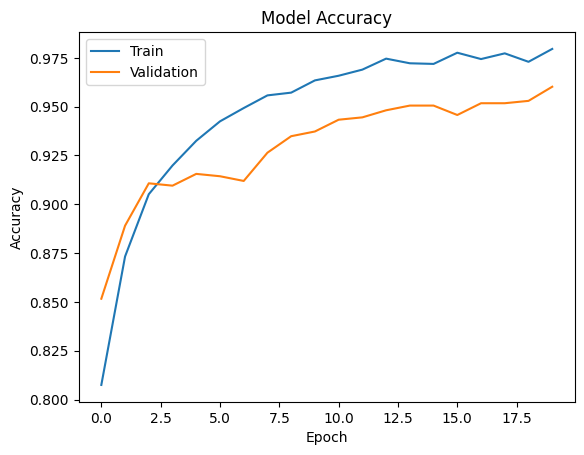

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])
plt.show()

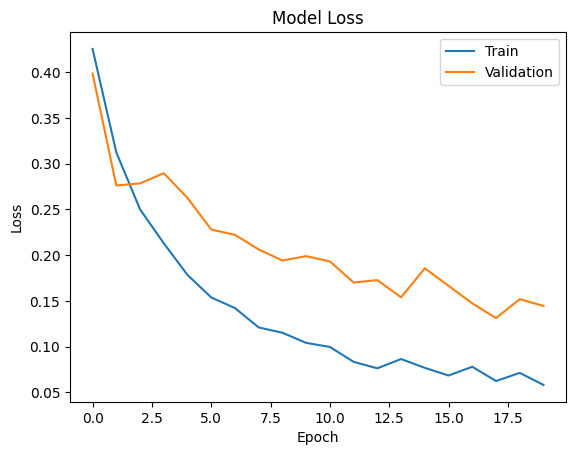

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])
plt.show()

In [33]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9517 - loss: 0.1311
Validation Loss: 0.13111460208892822
Validation Accuracy: 0.9517490863800049


In [34]:
print(train_generator.class_indices)

{'fractured': 0, 'not fractured': 1}


In [35]:
from google.colab import files

uploaded = files.upload()

Saving download.jpg to download.jpg


In [36]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
[[1.0000000e+00 1.4619887e-10]]


In [37]:
class_names = list(train_generator.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

Predicted Class: fractured


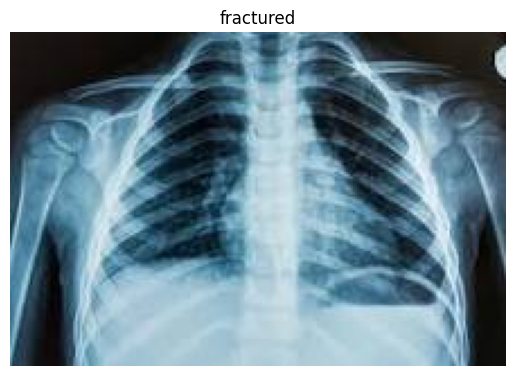

In [38]:
import matplotlib.pyplot as plt

img_display = image.load_img(img_path)

plt.imshow(img_display)
plt.title(predicted_class)
plt.axis('off')

plt.show()

In [39]:
model.save('/content/drive/MyDrive/final_bone_fracture_model.keras')

In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [41]:
Y_pred = model.predict(validation_generator)

y_pred = np.argmax(Y_pred, axis=1)

26/26 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step


In [42]:
y_true = validation_generator.classes

In [43]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[136 201]
 [193 299]]


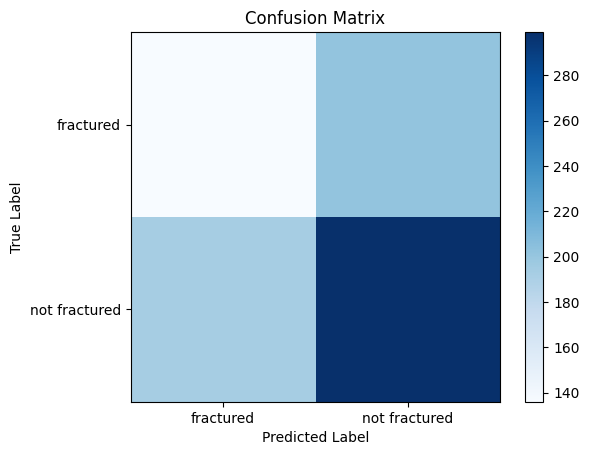

In [44]:
import matplotlib.pyplot as plt

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(train_generator.class_indices))
plt.xticks(tick_marks, train_generator.class_indices.keys())
plt.yticks(tick_marks, train_generator.class_indices.keys())

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [45]:
class_names = list(train_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

               precision    recall  f1-score   support

    fractured       0.41      0.40      0.41       337
not fractured       0.60      0.61      0.60       492

     accuracy                           0.52       829
    macro avg       0.51      0.51      0.51       829
 weighted avg       0.52      0.52      0.52       829



In [ ]:
from google.colab import files

uploaded = files.upload()

In [47]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

class_names = list(train_generator.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]

print("Prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Prediction: fractured


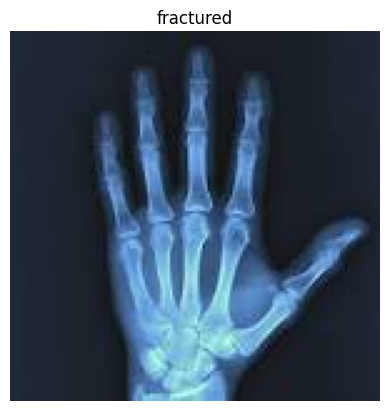

In [48]:
import matplotlib.pyplot as plt

img_display = image.load_img(img_path)

plt.imshow(img_display)
plt.title(predicted_class)
plt.axis('off')

plt.show()

In [49]:
model.save('/content/drive/MyDrive/final_bone_fracture_model.keras')

print("Final Model Saved!")

Final Model Saved!
